In [6]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from mlforecast import MLForecast
from mlforecast.utils import PredictionIntervals
from sklearn.ensemble import IsolationForest, RandomForestRegressor
from sklearn.neighbors import LocalOutlierFactor
from xgboost import XGBRegressor
from neuralforecast import NeuralForecast
from neuralforecast.losses.pytorch import MQLoss
from neuralforecast.models import NBEATS, NHITS

warnings.filterwarnings("ignore")

df = pd.read_csv("../data/traffic_clean.csv")
df["ds"] = pd.to_datetime(df["ds"])
df = df.sort_values(["unique_id", "ds"]).reset_index(drop=True)

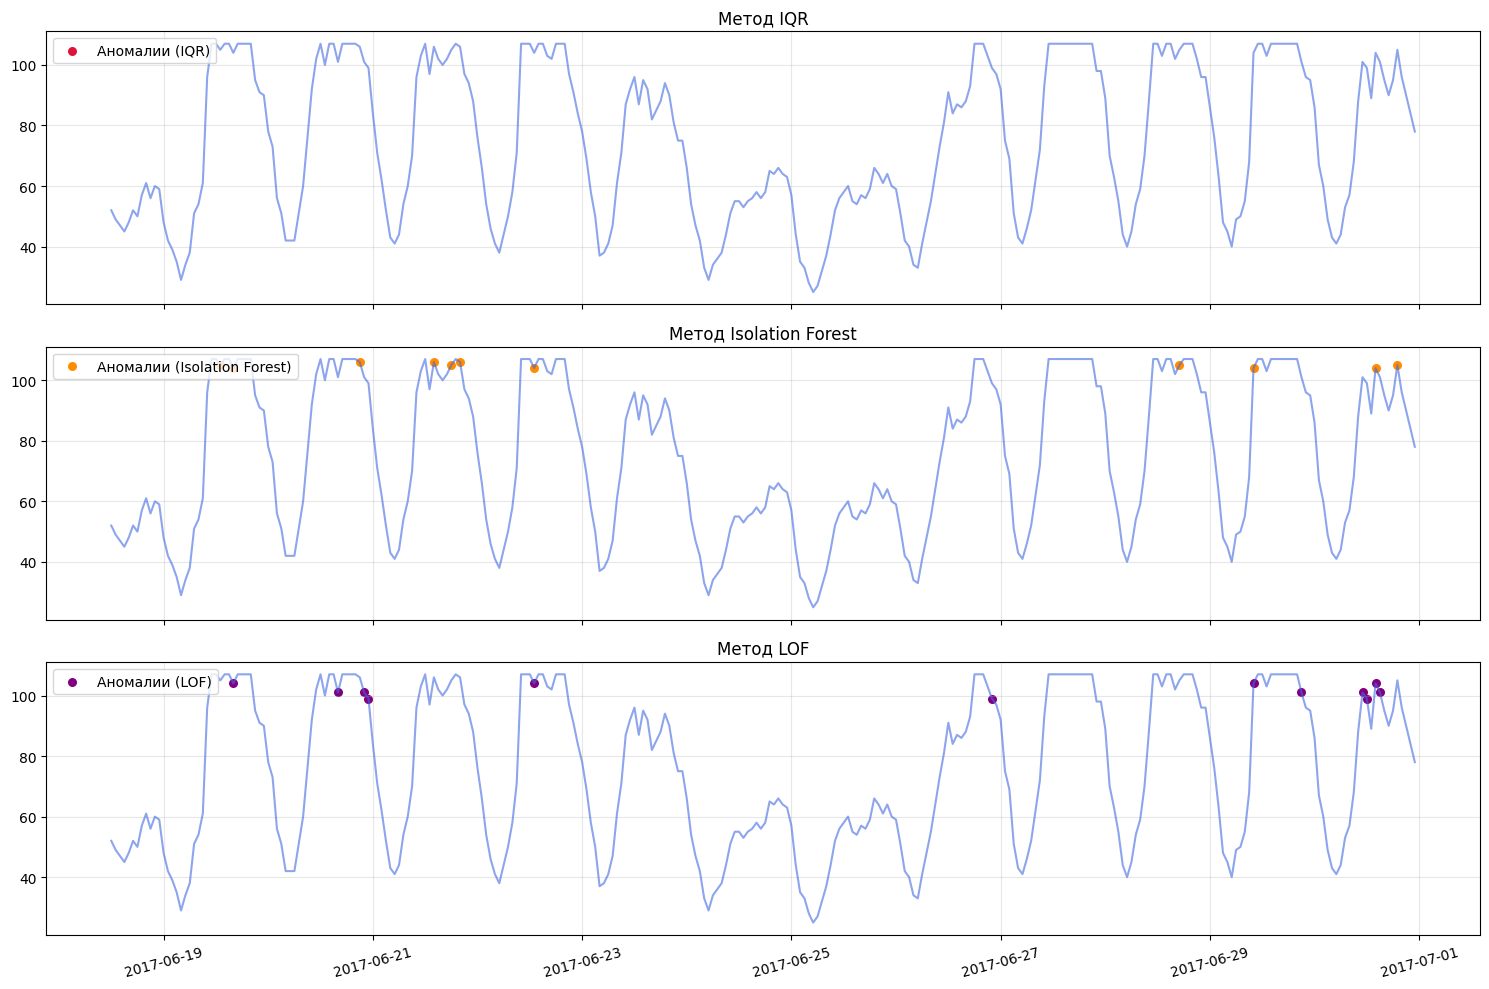

In [7]:
df_anom = df[df["unique_id"] == 1].copy().reset_index(drop=True)

# 1. IQR
q25, q75 = df_anom["y"].quantile(0.25), df_anom["y"].quantile(0.75)
iqr = q75 - q25
df_anom["anom_iqr"] = np.where(
    (df_anom["y"] < q25 - 1.5 * iqr) | (df_anom["y"] > q75 + 1.5 * iqr), -1, 1
)

# 2. Isolation Forest и 3. LOF
df_anom["anom_iforest"] = IsolationForest(
    contamination=0.01, random_state=42
).fit_predict(df_anom[["y"]])
df_anom["anom_lof"] = LocalOutlierFactor(
    n_neighbors=20, contamination=0.01
).fit_predict(df_anom[["y"]])

# Отрисовка через цикл для экономии места (берем срез для читаемости)
plot_data = df_anom.tail(300)
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

methods = [
    ("anom_iqr", "IQR", "crimson"),
    ("anom_iforest", "Isolation Forest", "darkorange"),
    ("anom_lof", "LOF", "purple"),
]

for i, (col, name, color) in enumerate(methods):
    axes[i].plot(plot_data["ds"], plot_data["y"], color="royalblue", alpha=0.6)
    outliers = plot_data[plot_data[col] == -1]
    axes[i].scatter(
        outliers["ds"],
        outliers["y"],
        color=color,
        s=30,
        label=f"Аномалии ({name})",
    )
    axes[i].set_title(f"Метод {name}")
    axes[i].legend(loc="upper left")
    axes[i].grid(True, alpha=0.3)

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [8]:
horizon = 24

fcst = MLForecast(
    models={
        "LightGBM": LGBMRegressor(random_state=42, n_estimators=100),
        "XGBoost": XGBRegressor(random_state=42, n_estimators=100),
        "RandomForest": RandomForestRegressor(
            random_state=42, n_estimators=50, n_jobs=-1
        ),
    },
    freq="H",
    lags=[1, 2, 24, 48],
    date_features=["hour", "dayofweek"],
)

# Параметр prediction_intervals перенесен сюда
cv_results = fcst.cross_validation(
    df=df[["unique_id", "ds", "y"]],
    h=horizon,
    n_windows=3,
    step_size=horizon,
    level=[80, 95],
    prediction_intervals=PredictionIntervals(n_windows=2, h=horizon),
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000163 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 467
[LightGBM] [Info] Number of data points in the train set: 43272, number of used features: 6
[LightGBM] [Info] Start training from score 23.915107
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000182 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 467
[LightGBM] [Info] Number of data points in the train set: 43416, number of used features: 6
[LightGBM] [Info] Start training from score 23.972579
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000176 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough,

In [9]:
def evaluate_intervals(cv_df, model_name, level):
    y_true = cv_df["y"]
    lower = cv_df[f"{model_name}-lo-{level}"]
    upper = cv_df[f"{model_name}-hi-{level}"]

    # Доля попаданий в коридор
    coverage = ((y_true >= lower) & (y_true <= upper)).mean()

    # Штраф за ширину и выходы за границы
    alpha = 1 - level / 100
    width = upper - lower
    penalty_lo = (2 / alpha) * (lower - y_true) * (y_true < lower)
    penalty_hi = (2 / alpha) * (y_true - upper) * (y_true > upper)
    winkler_score = (width + penalty_lo + penalty_hi).mean()

    return coverage, winkler_score


metrics_list = []
for model in ["LightGBM", "XGBoost", "RandomForest"]:
    for lvl in [80, 95]:
        cov, winkler = evaluate_intervals(cv_results, model, lvl)
        metrics_list.append(
            {
                "Модель": model,
                "Доверительный уровень": f"{lvl}%",
                "Покрытие (Coverage)": f"{cov:.2%}",
                "Winkler Score": round(winkler, 2),
            }
        )

pd.DataFrame(metrics_list)

,Модель,Доверительный уровень,Покрытие (Coverage),Winkler Score
0,LightGBM,80%,70.83%,17.77
1,LightGBM,95%,75.46%,35.58
2,XGBoost,80%,73.15%,19.69
3,XGBoost,95%,76.39%,34.28
4,RandomForest,80%,67.13%,18.76
5,RandomForest,95%,73.15%,39.75


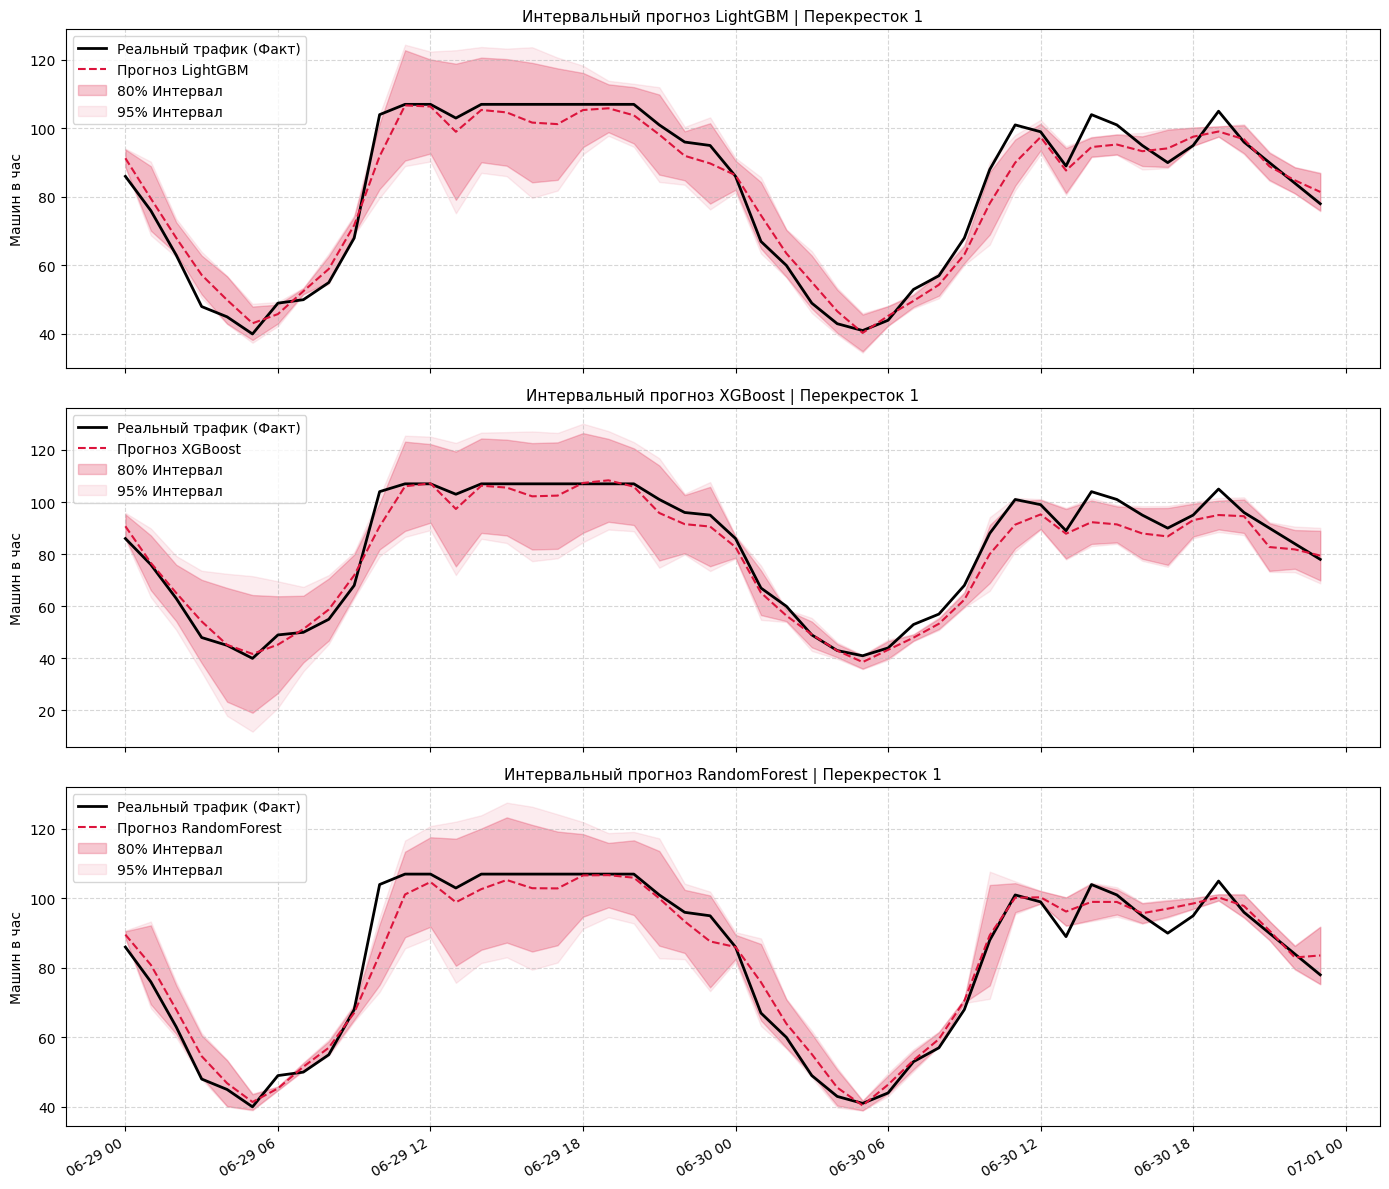

In [10]:
models = ["LightGBM", "XGBoost", "RandomForest"]

# Берем последние 48 часов для наглядности
plot_cv = cv_results[cv_results["unique_id"] == 1].tail(48)

# Создаем сетку графиков: по одному на каждую модель
fig, axes = plt.subplots(len(models), 1, figsize=(14, 12), sharex=True)

for i, model in enumerate(models):
    # Отрисовка факта и точечного прогноза
    axes[i].plot(
        plot_cv["ds"],
        plot_cv["y"],
        color="black",
        lw=2,
        label="Реальный трафик (Факт)",
    )
    axes[i].plot(
        plot_cv["ds"],
        plot_cv[model],
        color="crimson",
        linestyle="--",
        label=f"Прогноз {model}",
    )

    # Заливка доверительных интервалов
    axes[i].fill_between(
        plot_cv["ds"],
        plot_cv[f"{model}-lo-80"],
        plot_cv[f"{model}-hi-80"],
        color="crimson",
        alpha=0.23,
        label="80% Интервал",
    )
    axes[i].fill_between(
        plot_cv["ds"],
        plot_cv[f"{model}-lo-95"],
        plot_cv[f"{model}-hi-95"],
        color="crimson",
        alpha=0.08,
        label="95% Интервал",
    )

    # Настройка подписей и сетки для каждого сабплота
    axes[i].set_title(
        f"Интервальный прогноз {model} | Перекресток 1", fontsize=11
    )
    axes[i].set_ylabel("Машин в час")
    axes[i].grid(True, linestyle="--", alpha=0.5)
    axes[i].legend(loc="upper left")

# Красиво форматируем даты на нижней оси
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

In [19]:
import pandas as pd
from neuralforecast import NeuralForecast
from neuralforecast.losses.pytorch import MQLoss
from neuralforecast.models import LSTM, NBEATS, NHITS

horizon = 24
# Квантили для 80% и 95% коридоров + 0.5 (медиана для центральной линии прогноза)
quantiles = [0.025, 0.1, 0.5, 0.9, 0.975]

dl_models = [
    NHITS(
        h=horizon,
        input_size=2 * horizon,  # Окно ретроспективы (48 часов)
        loss=MQLoss(quantiles=quantiles),
        max_steps=150,
        scaler_type="standard",
    ),
    NBEATS(
        h=horizon,
        input_size=2 * horizon,
        loss=MQLoss(quantiles=quantiles),
        max_steps=150,
        scaler_type="standard",
    ),
    LSTM(
        h=horizon,
        input_size=2 * horizon,
        loss=MQLoss(quantiles=quantiles),
        max_steps=150,
        scaler_type="standard",
    ),
]

nf = NeuralForecast(models=dl_models, freq="H")

# Строгая кросс-валидация на 3 фолдах (идентично ML-схеме проекта)
cv_results_dl = nf.cross_validation(
    df=df[["unique_id", "ds", "y"]],
    h=horizon,
    n_windows=3,
    step_size=horizon,
)

cv_results_dl = cv_results_dl.reset_index()

Seed set to 1
Seed set to 1
Seed set to 1
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MQLoss        | 5      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 2.6 M  | train
-------------------------------------------------------
2.6 M     Trainable params
5         Non-trainable params
2.6 M     Total params
10.385    Total estimated model params size (MB)
34        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=150` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=150` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

In [20]:
def evaluate_intervals_dl(cv_df, model_name, level):
    y_true = cv_df["y"]
    col_lo, col_hi = None, None

    # Автоматический парсинг названий квантилей во избежание KeyError
    if level == 80:
        for col in cv_df.columns:
            if col.startswith(model_name) and "quantile" in col:
                if "-0.1" in col or "-0.10" in col:
                    col_lo = col
                if "-0.9" in col or "-0.90" in col:
                    col_hi = col
    elif level == 95:
        for col in cv_df.columns:
            if col.startswith(model_name) and "quantile" in col:
                if "-0.025" in col:
                    col_lo = col
                if "-0.975" in col:
                    col_hi = col

    # Запасной вариант наименования колонок
    if col_lo is None or col_hi is None:
        for col in cv_df.columns:
            if col.startswith(model_name):
                if level == 80 and ("lo-80" in col or "low-80" in col):
                    col_lo = col
                if level == 80 and ("hi-80" in col or "high-80" in col):
                    col_hi = col
                if level == 95 and ("lo-95" in col or "low-95" in col):
                    col_lo = col
                if level == 95 and ("hi-95" in col or "high-95" in col):
                    col_hi = col

    if col_lo is None or col_hi is None:
        raise KeyError(
            f"Не найдены интервалы для {model_name} ({level}%). Колонки: {list(cv_df.columns)}"
        )

    lower = cv_df[col_lo]
    upper = cv_df[col_hi]

    # Расчет метрик
    coverage = ((y_true >= lower) & (y_true <= upper)).mean()
    alpha = 1 - level / 100
    width = upper - lower
    penalty_lo = (2 / alpha) * (lower - y_true) * (y_true < lower)
    penalty_hi = (2 / alpha) * (y_true - upper) * (y_true > upper)
    winkler_score = (width + penalty_lo + penalty_hi).mean()

    return coverage, winkler_score


# Сборка лидерборда
metrics_dl = []
for model in ["NHITS", "NBEATS", "LSTM"]:
    for lvl in [80, 95]:
        cov, winkler = evaluate_intervals_dl(cv_results_dl, model, lvl)
        metrics_dl.append(
            {
                "Модель": model,
                "Доверительный уровень": f"{lvl}%",
                "Покрытие (Coverage)": f"{cov:.2%}",
                "Winkler Score": round(winkler, 2),
            }
        )

pd.DataFrame(metrics_dl)

,Модель,Доверительный уровень,Покрытие (Coverage),Winkler Score
0,NHITS,80%,84.26%,17.80
1,NHITS,95%,96.76%,28.90
2,NBEATS,80%,83.33%,16.73
3,NBEATS,95%,96.76%,28.35
4,LSTM,80%,96.30%,29.03
5,LSTM,95%,99.07%,58.67


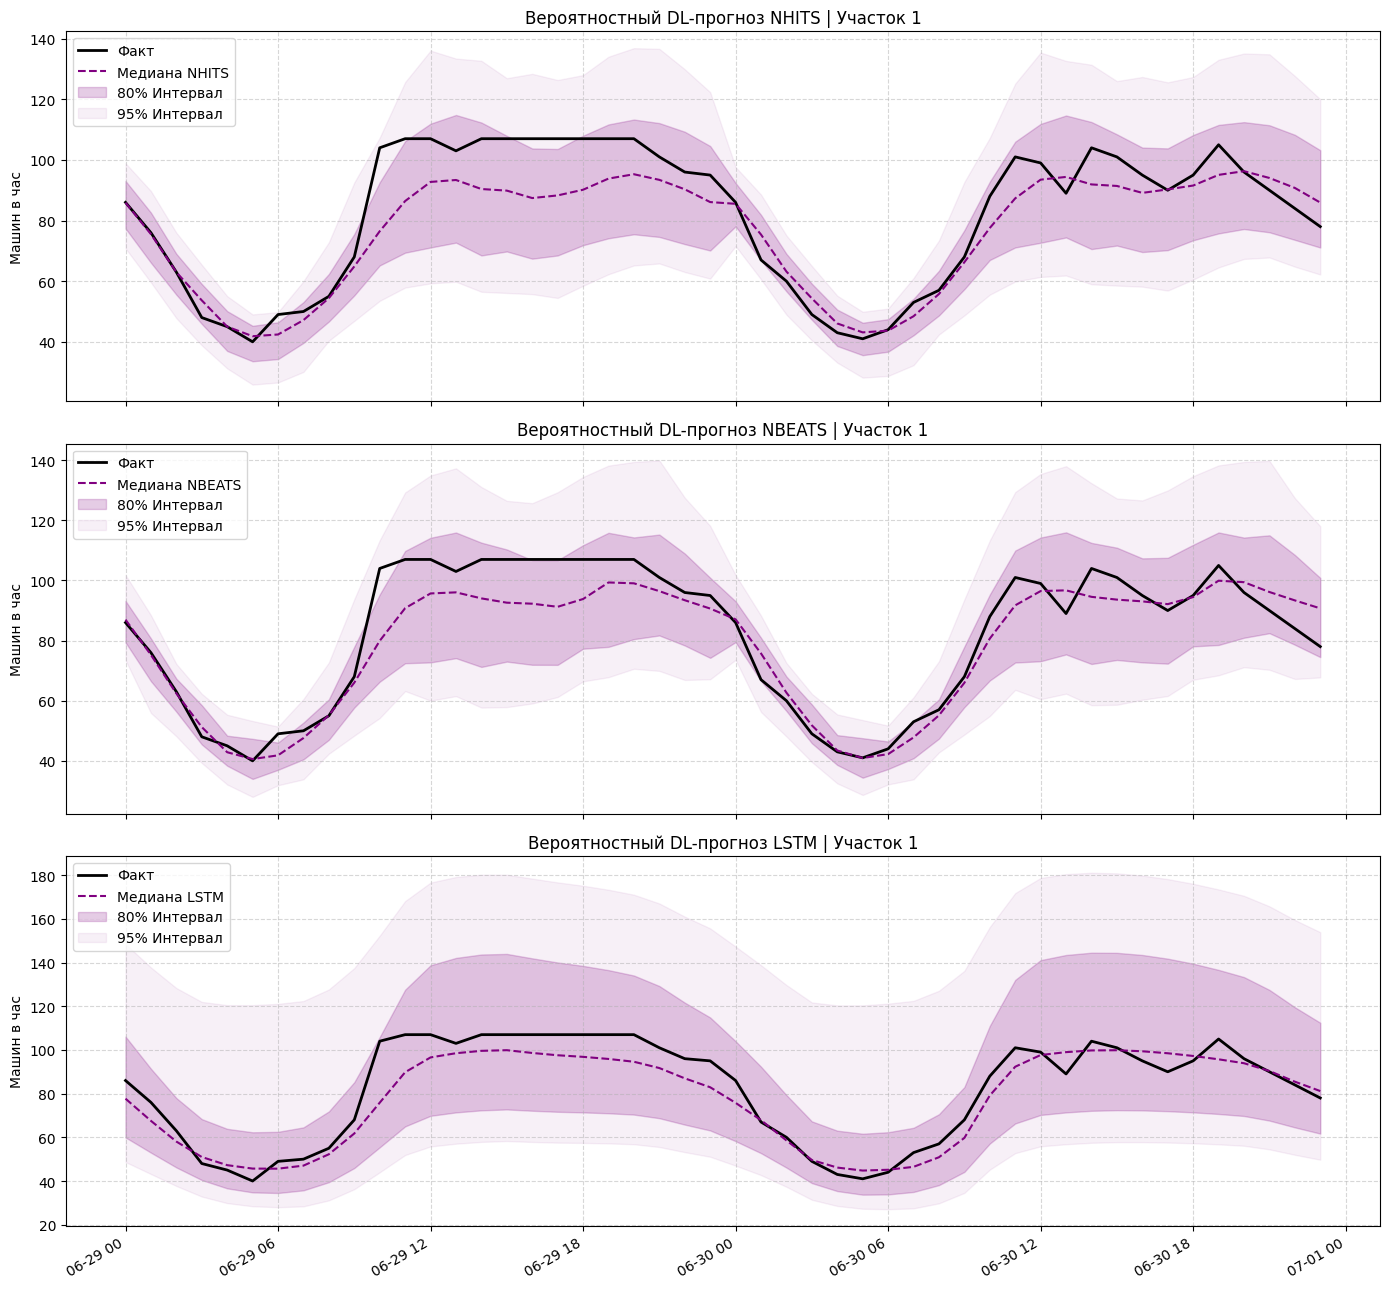

In [21]:
import matplotlib.pyplot as plt

dl_list = ["NHITS", "NBEATS", "LSTM"]
plot_dl = cv_results_dl[cv_results_dl["unique_id"] == 1].tail(48)

fig, axes = plt.subplots(len(dl_list), 1, figsize=(14, 13), sharex=True)

for i, model in enumerate(dl_list):
    # Исторический факт
    axes[i].plot(
        plot_dl["ds"], plot_dl["y"], color="black", lw=2, label="Факт"
    )

    # Поиск колонки точечного прогноза (медианы)
    median_col = None
    for col in plot_dl.columns:
        if (
            col == model
            or col == f"{model}-median"
            or f"{model}-quantile-0.5" in col
            or f"{model}-quantile-0.50" in col
        ):
            median_col = col
            break

    if median_col:
        axes[i].plot(
            plot_dl["ds"],
            plot_dl[median_col],
            color="purple",
            linestyle="--",
            label=f"Медиана {model}",
        )

    # Динамический поиск границ для графиков
    q80_lo, q80_hi, q95_lo, q95_hi = None, None, None, None
    for col in plot_dl.columns:
        if col.startswith(model):
            if "quantile-0.1" in col or "quantile-0.10" in col or "lo-80" in col:
                q80_lo = col
            if "quantile-0.9" in col or "quantile-0.90" in col or "hi-80" in col:
                q80_hi = col
            if "quantile-0.025" in col or "lo-95" in col:
                q95_lo = col
            if "quantile-0.975" in col or "hi-95" in col:
                q95_hi = col

    # Отрисовка доверительных коридоров
    if q80_lo and q80_hi:
        axes[i].fill_between(
            plot_dl["ds"],
            plot_dl[q80_lo],
            plot_dl[q80_hi],
            color="purple",
            alpha=0.20,
            label="80% Интервал",
        )

    if q95_lo and q95_hi:
        axes[i].fill_between(
            plot_dl["ds"],
            plot_dl[q95_lo],
            plot_dl[q95_hi],
            color="purple",
            alpha=0.06,
            label="95% Интервал",
        )

    axes[i].set_title(f"Вероятностный DL-прогноз {model} | Участок 1")
    axes[i].set_ylabel("Машин в час")
    axes[i].grid(True, linestyle="--", alpha=0.5)
    axes[i].legend(loc="upper left")

plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

In [24]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("=== ТОЧЕЧНЫЕ МЕТРИКИ ДЛЯ ML МОДЕЛЕЙ ===")
# Переменная cv_results из твоей 2-й ячейки
ml_models = ["LightGBM", "XGBoost", "RandomForest"]
for model in ml_models:
    if model in cv_results.columns:
        # Исключаем пропуски на всякий случай
        mask = cv_results["y"].notna() & cv_results[model].notna()
        y_true = cv_results.loc[mask, "y"]
        y_pred = cv_results.loc[mask, model]

        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        print(f"{model} -> MAE: {mae:.2f} | RMSE: {rmse:.2f}")
    else:
        print(f"Модель {model} не найдена в cv_results")

print("\n=== ТОЧЕЧНЫЕ МЕТРИКИ ДЛЯ DL МОДЕЛЕЙ ===")
# Переменная cv_results_dl из твоей 5-й ячейки
dl_models = ["NHITS", "NBEATS", "LSTM"]
for model in dl_models:
    # Ищем колонку медианы (quantile-0.5), как ты делаешь в графиках ячейки №7
    median_col = None
    for col in cv_results_dl.columns:
        if (
            col == model
            or col == f"{model}-median"
            or f"{model}-quantile-0.5" in col
            or f"{model}-quantile-0.50" in col
        ):
            median_col = col
            break

    if median_col:
        mask = cv_results_dl["y"].notna() & cv_results_dl[median_col].notna()
        y_true = cv_results_dl.loc[mask, "y"]
        y_pred = cv_results_dl.loc[mask, median_col]

        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        print(f"{model} -> MAE: {mae:.2f} | RMSE: {rmse:.2f}")
    else:
        print(f"Колонка медианы для {model} не найдена в cv_results_dl.")

=== ТОЧЕЧНЫЕ МЕТРИКИ ДЛЯ ML МОДЕЛЕЙ ===
LightGBM -> MAE: 3.20 | RMSE: 4.35
XGBoost -> MAE: 3.80 | RMSE: 5.04
RandomForest -> MAE: 3.10 | RMSE: 4.33

=== ТОЧЕЧНЫЕ МЕТРИКИ ДЛЯ DL МОДЕЛЕЙ ===
NHITS -> MAE: 3.95 | RMSE: 5.76
NBEATS -> MAE: 3.37 | RMSE: 4.85
LSTM -> MAE: 4.51 | RMSE: 6.05
